In [37]:
%pip install seaborn

Note: you may need to restart the kernel to use updated packages.


In [38]:
import pandas as pd
import os

#read all data files
print("Reading data from file...")
seg_stat=pd.read_csv("../data/segment_status.csv")
print("Reading data from file...")
seg=pd.read_csv("segments.csv")
print("Reading data from file...")
streets=pd.read_csv("streets.csv")
print("Reading data from file...")
nodes=pd.read_csv("../data/nodes.csv")


Reading data from file...
Reading data from file...
Reading data from file...
Reading data from file...


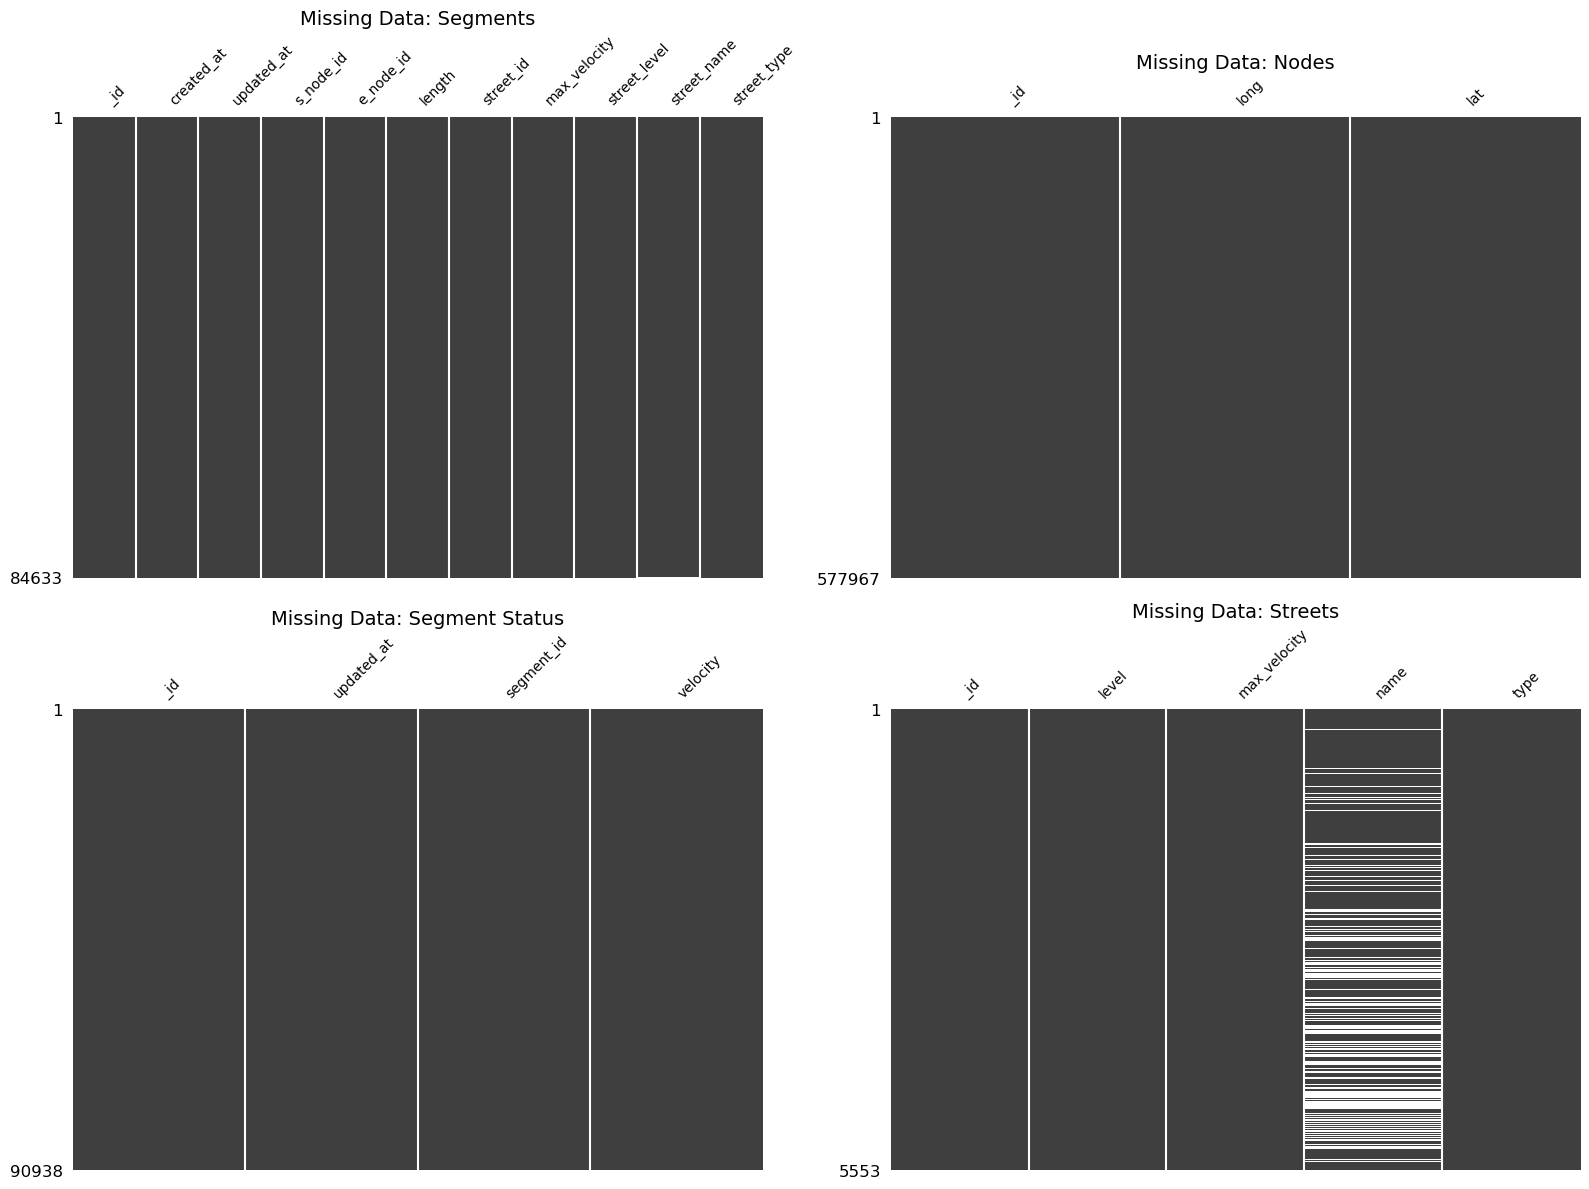

In [39]:
import pandas as pd
import missingno as msno
import matplotlib.pyplot as plt

# Check all dataset to find any nullable
# show missing values of data_streets
datasets = [
    (seg, "Segments"),
    (nodes, "Nodes"),
    (seg_stat, "Segment Status"),
    (streets, "Streets")
]
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(16, 12))
axes_flat = axes.flatten()

for i, (df, name) in enumerate(datasets):
    msno.matrix(df, ax=axes_flat[i], sparkline=False, fontsize=10)
    axes_flat[i].set_title(f"Missing Data: {name}", fontsize=14)

plt.tight_layout()
plt.show()


In [40]:
import pandas as pd

# Remove nullable name
streets.dropna(subset=['name'], inplace=True)

seg = seg[seg['street_id'].isin(streets['_id'])]

seg_stat = seg_stat[seg_stat['segment_id'].isin(seg['_id'])]

print("Đã xóa các bản ghi lỗi và đồng bộ dữ liệu thành công!")

Đã xóa các bản ghi lỗi và đồng bộ dữ liệu thành công!


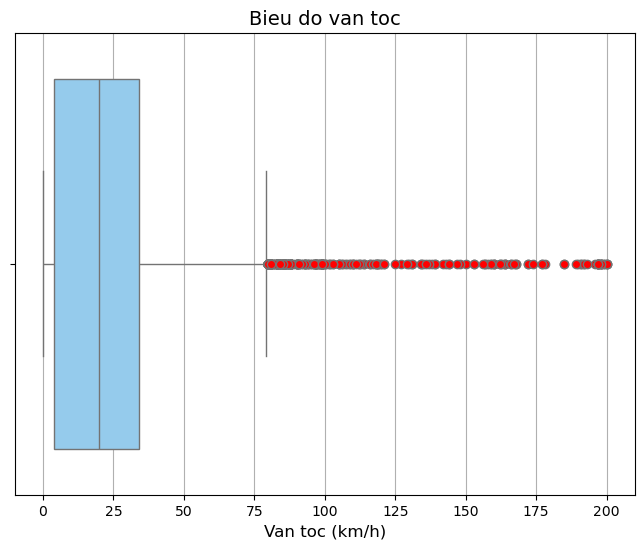

In [41]:
#check outers of segment_status
import matplotlib.pyplot as plt
import seaborn as sbn

plt.figure(figsize=(8,6))
sbn.boxplot(data=seg_stat, x='velocity', color='lightskyblue', flierprops={'markerfacecolor': 'red', 'marker': 'o'})

# Them tieu de va nhan truc
plt.title('Bieu do van toc', fontsize=14)
plt.xlabel('Van toc (km/h)', fontsize=12)

# Hien thi bieu do
plt.grid(axis='x', alpha=1)
plt.show()

In [42]:
# See all outliers

q1=seg_stat['velocity'].quantile(0.25)
q3=seg_stat['velocity'].quantile(0.75)
iqr=q3-q1

lower_bound=q1-1.5*iqr
upper_bound=q3+1.5*iqr
outliers=seg_stat[seg_stat['velocity']>upper_bound]
print(f"Số lượng ngoại biên:{len(outliers)}")
print(outliers)


Số lượng ngoại biên:384
         _id                updated_at  segment_id  velocity
37899  37899  2020-09-10T13:10:27.262Z       23382       100
38289  38289  2020-11-01T03:44:07.085Z       56816        99
38290  38290  2020-11-01T04:02:05.666Z       56816        99
38293  38293  2020-11-01T04:15:23.623Z       56816        88
38294  38294  2020-11-01T04:16:51.545Z       56816        88
...      ...                       ...         ...       ...
89787  89787  2021-04-21T22:25:41.483Z       84149        85
89796  89796  2021-04-21T22:27:30.346Z       84122        99
89987  89987  2021-04-22T01:39:50.153Z       37793        91
89988  89988  2021-04-22T01:40:04.342Z       57936       162
90082  90082  2021-04-22T01:57:41.408Z       41692        84

[384 rows x 4 columns]


In [43]:
# Delete all outliers records
seg_stat.drop(index=outliers.index, inplace=True)
print(f"Đã xóa xong! Số lượng bản ghi còn lại trong seg_stat: {len(seg_stat)}")

Đã xóa xong! Số lượng bản ghi còn lại trong seg_stat: 75456


C:\Users\caonh\AppData\Local\Temp\ipykernel_19604\2649141541.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  seg_stat.drop(index=outliers.index, inplace=True)


In [ ]:
import pandas as pd
import numpy as np

# Đảm bảo định dạng thời gian cho bảng gốc seg_stat
seg_stat['updated_at'] = pd.to_datetime(seg_stat['updated_at'])

# --- BƯỚC 1: XÁC ĐỊNH TOP 10 CON ĐƯỜNG (STREETS) NHIỀU RECORD NHẤT ---
seg_street_map = seg[['_id', 'street_id']].rename(columns={'_id': 'segment_id'})
temp_count = pd.merge(seg_stat, seg_street_map, on='segment_id', how='inner')

top_10_streets = temp_count['street_id'].value_counts().head(10).index.tolist()
print(f"Top 10 Street ID được chọn: {top_10_streets}")

# --- BƯỚC 2: LẤY TẤT CẢ SEGMENTS THUỘC 10 CON ĐƯỜNG NÀY ---
target_segments_df = seg[seg['street_id'].isin(top_10_streets)]
target_segments_list = target_segments_df['_id'].unique().tolist()
print(f"Tổng số phân đoạn (segments) thuộc 10 con đường trên: {len(target_segments_list)}")

# Lọc bảng dữ liệu gốc seg_stat theo danh sách phân đoạn này
seg_stat_filtered = seg_stat[seg_stat['segment_id'].isin(target_segments_list)].copy()

# --- BƯỚC 3: SỬA ĐỔI TẠI ĐÂY - TẠO TRỤC THỜI GIAN CHUẨN TRONG ĐÚNG 7 NGÀY ---
start_date = seg_stat_filtered['updated_at'].min()
# Giới hạn ngày kết thúc bằng ngày bắt đầu cộng thêm 7 ngày
end_date = start_date + pd.Timedelta(days=7)

full_time_range = pd.date_range(start=start_date, end=end_date, freq='15min')
print(f"Phạm vi thời gian được thu hẹp từ: {start_date} đến {end_date} (Đúng 7 ngày)")

# --- BƯỚC 4: TẠO TỪ ĐIỂN MAX_VELOCITY CỦA TOÀN BỘ SEGMENT MỤC TIÊU ---
max_vel_map = target_segments_df.set_index('_id')['max_velocity'].to_dict()

# --- BƯỚC 5: PIVOT MA TRẬN VÀ ĐIỀN DỮ LIỆU ĐỘNG THEO GIỜ CAO ĐIỂM ---
matrix = seg_stat_filtered.pivot_table(index='updated_at', columns='segment_id', values='velocity', aggfunc='mean')
# Ép ma trận theo khung 7 ngày vừa tạo (các mốc ngoài 7 ngày này hoặc mốc missing sẽ thành NaN)
matrix = matrix.reindex(full_time_range)

morning_start = pd.to_datetime('06:30').time()
morning_end = pd.to_datetime('09:15').time()
evening_start = pd.to_datetime('16:30').time()
evening_end = pd.to_datetime('18:45').time()

# Duyệt qua toàn bộ phân đoạn thuộc 10 con đường lớn
for segment in target_segments_list:
    if segment not in matrix.columns:
        matrix[segment] = np.nan
        
    max_vel = max_vel_map.get(segment, 50)
    max_vel = 50 if (pd.isna(max_vel) or max_vel == 0) else max_vel
    
    fill_series = []
    for current_timestamp in matrix.index:
        current_time = current_timestamp.time()
        noise = np.random.uniform(-3, 3)
        
        # Giờ cao điểm
        if (morning_start <= current_time <= morning_end) or (evening_start <= current_time <= evening_end):
            ratio = np.random.uniform(0.20, 0.38)
            sim_vel = (max_vel * ratio) + noise
        else: # Giờ thấp điểm
            ratio = np.random.uniform(0.78, 0.95)
            sim_vel = (max_vel * ratio) + noise
            
        fill_series.append(max(min(sim_vel, max_vel), 5))
        
    matrix[segment] = matrix[segment].fillna(pd.Series(fill_series, index=matrix.index))

# --- BƯỚC 6: BIẾN ĐỔI NGƯỢC VỀ BẢNG DỌC VÀ GÁN ĐÈ SEG_STAT ---
matrix.index.name = 'updated_at'
seg_stat_updated = matrix.reset_index().melt(
    id_vars=['updated_at'],
    var_name='segment_id',
    value_name='velocity'
)

seg_stat_updated['segment_id'] = seg_stat_updated['segment_id'].astype(int)
seg_stat_updated['_id'] = range(1, len(seg_stat_updated) + 1)
seg_stat_updated = seg_stat_updated[['_id', 'updated_at', 'segment_id', 'velocity']]

# GÁN ĐÈ DỮ LIỆU ĐÃ CO HẸP 7 NGÀY VÀO BIẾN CŨ
seg_stat = seg_stat_updated.reset_index(drop=True)

print("\nĐã tạo xong dữ liệu ảo liên tục cho TẤT CẢ các phân đoạn thuộc 10 con đường lớn trong vòng 7 ngày!")
print(f"Tổng số bản ghi hiện tại của hệ thống: {len(seg_stat)}")

Top 10 Street ID được chọn: [408212916, 32928925, 32587814, 211408582, 227738147, 35114023, 330035862, 32579641, 32577449, 32577828]
Tổng số phân đoạn (segments) thuộc 10 con đường trên: 603
Phạm vi thời gian được thu hẹp từ: 2020-07-06 01:09:30.996000+00:00 đến 2020-07-13 01:09:30.996000+00:00 (Đúng 7 ngày)


C:\Users\caonh\AppData\Local\Temp\ipykernel_19604\2306440333.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  seg_stat['updated_at'] = pd.to_datetime(seg_stat['updated_at'])
C:\Users\caonh\AppData\Local\Temp\ipykernel_19604\2306440333.py:46: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  matrix[segment] = np.nan
C:\Users\caonh\AppData\Local\Temp\ipykernel_19604\2306440333.py:46: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor perfor


Đã tạo xong dữ liệu ảo liên tục cho TẤT CẢ các phân đoạn thuộc 10 con đường lớn trong vòng 7 ngày!
Tổng số bản ghi hiện tại của hệ thống: 405819


In [45]:
import pandas as pd

# 1. Tính toán số mốc thời gian lý thuyết dựa trên min và max của dữ liệu
min_time = seg_stat['updated_at'].min()
max_time = seg_stat['updated_at'].max()
total_days = (max_time - min_time).days + 1
expected_slots_per_segment = len(pd.date_range(start=min_time, end=max_time, freq='15min'))

print("--- THÔNG SỐ LÝ THUYẾT KHUNG CHUẨN 15 PHÚT ---")
print(f"Tổng khoảng thời gian: Từ {min_time} đến {max_time} (~{total_days} ngày)")
print(f"Số lượng mốc thời gian bắt buộc phải có cho MỖI segment: {expected_slots_per_segment}\n")

# 2. Kiểm tra thực tế trên biến seg_stat hiện tại
print("--- THỰC TẾ TRÊN BIẾN SEG_STAT MỚI ---")
# Đếm số lượng timestamp duy nhất của từng segment_id
check_df = seg_stat.groupby('segment_id')['updated_at'].nunique().reset_index(name='actual_slots')

# Kiểm tra xem có ô nào bị Null nữa không
missing_values_count = seg_stat['velocity'].isna().sum()
check_df['Trạng thái điền đầy'] = check_df['actual_slots'].apply(
    lambda x: "HOÀN HẢO (100% Đầy Đủ)" if x == expected_slots_per_segment else "THIẾU SÓT"
)

print(check_df.to_string(index=False))
print(f"\nSố lượng ô trống (NaN) còn sót lại trong cột velocity: {missing_values_count}")

--- THÔNG SỐ LÝ THUYẾT KHUNG CHUẨN 15 PHÚT ---
Tổng khoảng thời gian: Từ 2020-07-06 01:09:30.996000+00:00 đến 2020-07-13 01:09:30.996000+00:00 (~8 ngày)
Số lượng mốc thời gian bắt buộc phải có cho MỖI segment: 673

--- THỰC TẾ TRÊN BIẾN SEG_STAT MỚI ---
 segment_id  actual_slots    Trạng thái điền đầy
       2399           673 HOÀN HẢO (100% Đầy Đủ)
       2400           673 HOÀN HẢO (100% Đầy Đủ)
       2401           673 HOÀN HẢO (100% Đầy Đủ)
       2402           673 HOÀN HẢO (100% Đầy Đủ)
       2403           673 HOÀN HẢO (100% Đầy Đủ)
       2404           673 HOÀN HẢO (100% Đầy Đủ)
       2405           673 HOÀN HẢO (100% Đầy Đủ)
       2406           673 HOÀN HẢO (100% Đầy Đủ)
       2407           673 HOÀN HẢO (100% Đầy Đủ)
       2408           673 HOÀN HẢO (100% Đầy Đủ)
       2409           673 HOÀN HẢO (100% Đầy Đủ)
       2410           673 HOÀN HẢO (100% Đầy Đủ)
       2411           673 HOÀN HẢO (100% Đầy Đủ)
       2412           673 HOÀN HẢO (100% Đầy Đủ)
       2413

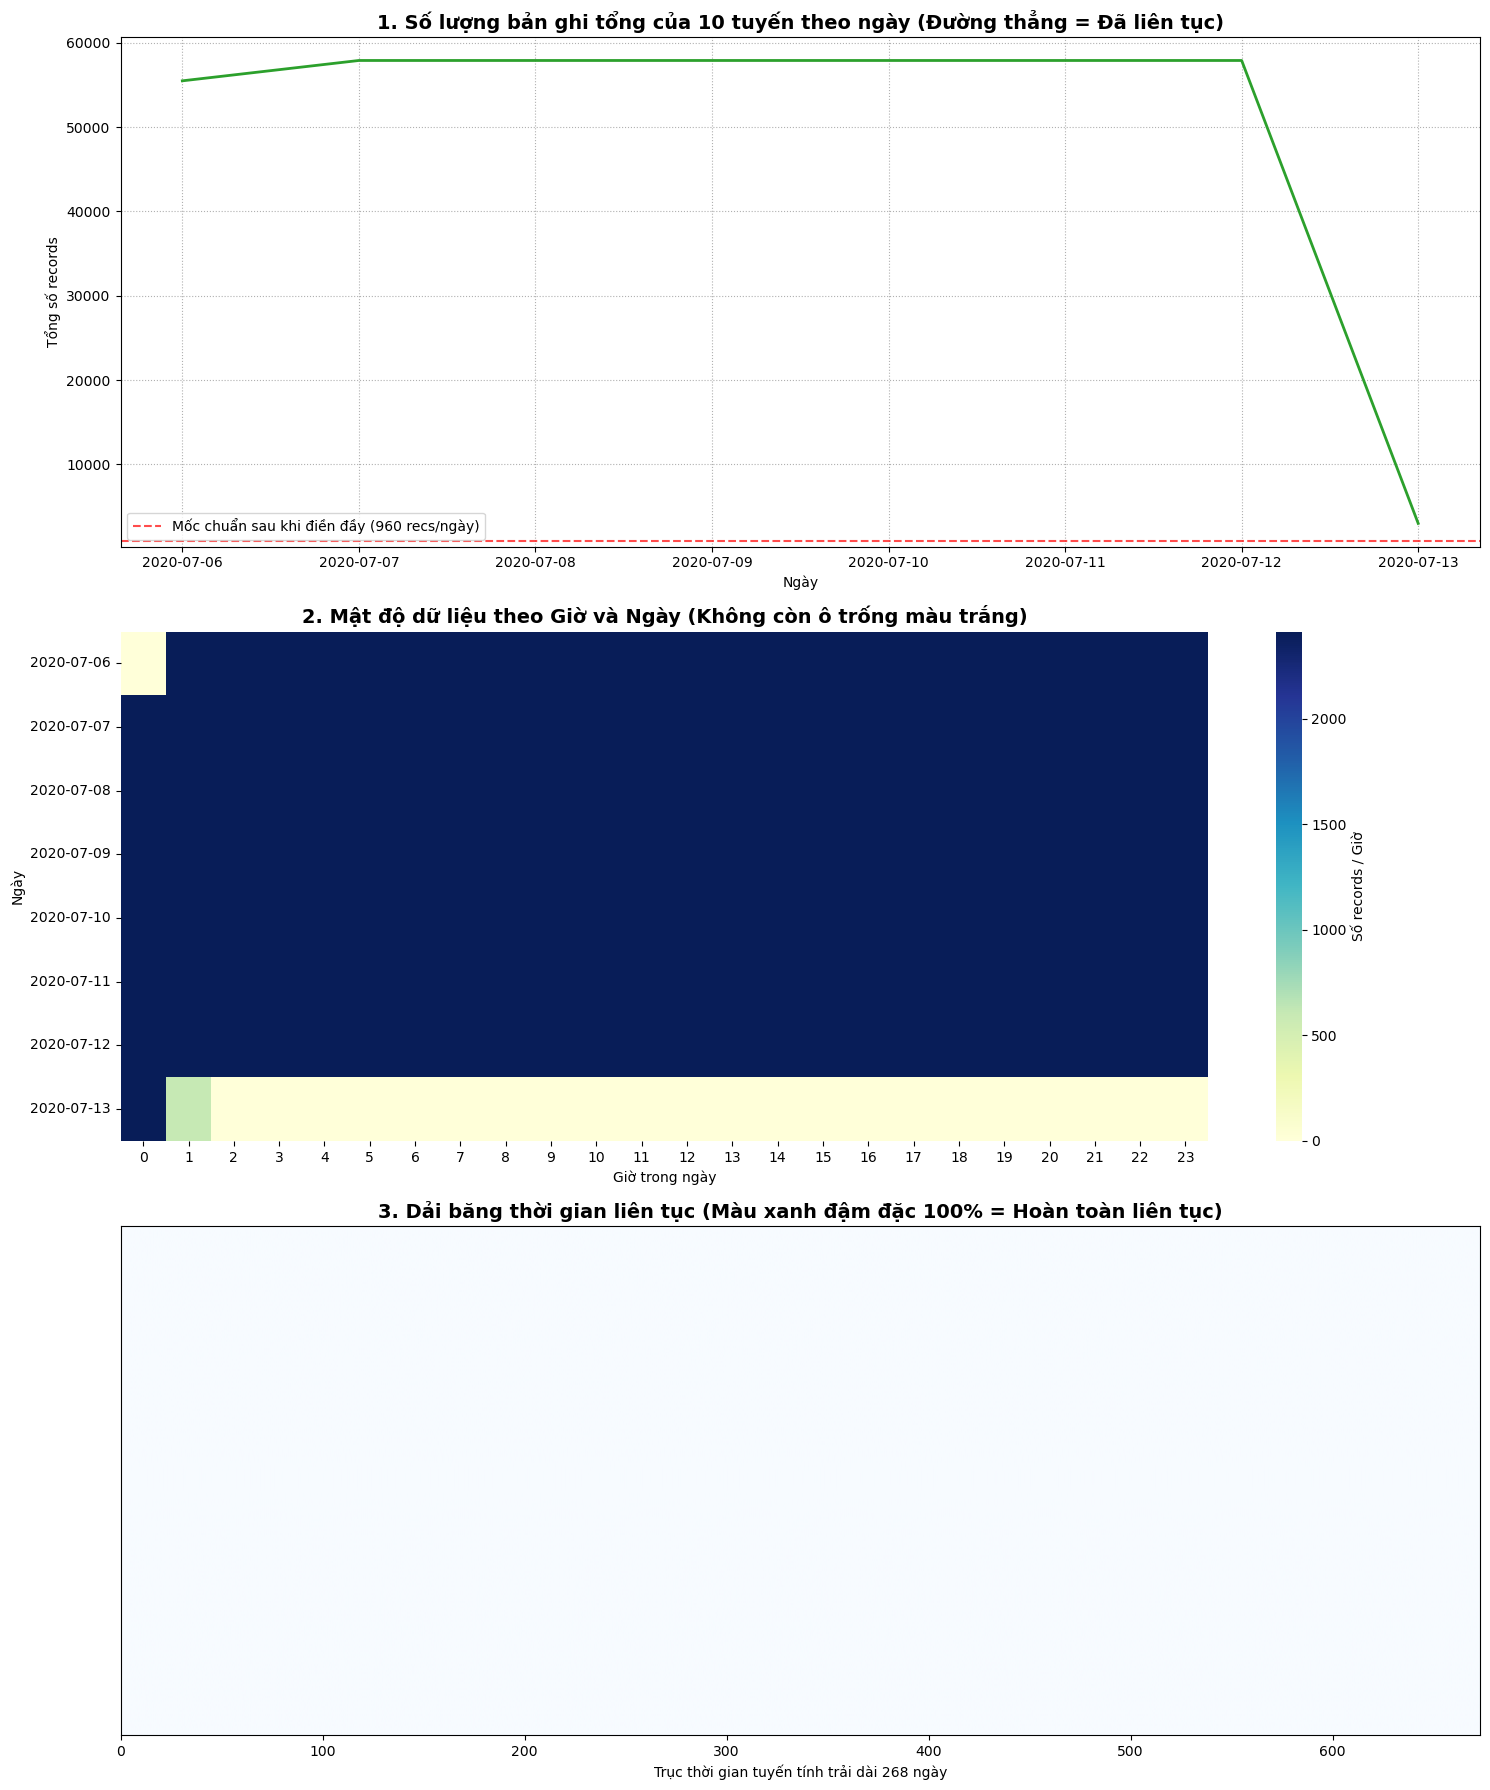

In [46]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Giả định biến seg_stat hiện tại là bảng dữ liệu 10 tuyến đã được lấp đầy của bạn
seg_stat['updated_at'] = pd.to_datetime(seg_stat['updated_at'])
seg_stat['date'] = seg_stat['updated_at'].dt.date
seg_stat['hour'] = seg_stat['updated_at'].dt.hour

# Khởi tạo khung vẽ 3 biểu đồ
fig, axes = plt.subplots(3, 1, figsize=(15, 18))

# 1. Biểu đồ Đường: Tổng số lượng bản ghi của 10 tuyến theo từng ngày
daily_counts = seg_stat.groupby('date').size().reset_index(name='count')
daily_counts['date'] = pd.to_datetime(daily_counts['date'])

axes[0].plot(daily_counts['date'], daily_counts['count'], color='#2ca02c', linewidth=2)
# Mốc lý thuyết: 10 tuyến * 96 mốc = 960 records/ngày
axes[0].axhline(y=960, color='r', linestyle='--', alpha=0.7, label='Mốc chuẩn sau khi điền đầy (960 recs/ngày)')
axes[0].set_title('1. Số lượng bản ghi tổng của 10 tuyến theo ngày (Đường thẳng = Đã liên tục)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Ngày')
axes[0].set_ylabel('Tổng số records')
axes[0].grid(True, linestyle=':')
axes[0].legend()

# 2. Biểu đồ Heatmap: Mật độ dữ liệu theo Giờ và Ngày (Gom cụm xem toàn cảnh)
heatmap_data = seg_stat.groupby(['date', 'hour']).size().unstack(fill_value=0)
sns.heatmap(heatmap_data, cmap='YlGnBu', ax=axes[1], cbar_kws={'label': 'Số records / Giờ'})
axes[1].set_title('2. Mật độ dữ liệu theo Giờ và Ngày (Không còn ô trống màu trắng)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Giờ trong ngày')
axes[1].set_ylabel('Ngày')

# 3. Biểu đồ Vạch kẻ (Missingness): Trực quan dải băng thời gian liên tục
full_time = pd.date_range(start=seg_stat['updated_at'].min(), end=seg_stat['updated_at'].max(), freq='15min')
presence_df = pd.DataFrame(index=full_time)
# Kiểm tra xem mốc thời gian có tồn tại trong dữ liệu không
presence_df['has_data'] = presence_df.index.isin(seg_stat['updated_at']).astype(int)

axes[2].imshow([presence_df['has_data']], cmap='Blues', aspect='auto', extent=[0, len(full_time), 0, 1])
axes[2].set_title('3. Dải băng thời gian liên tục (Màu xanh đậm đặc 100% = Hoàn toàn liên tục)', fontsize=14, fontweight='bold')
axes[2].set_yticks([])
axes[2].set_xlabel('Trục thời gian tuyến tính trải dài 268 ngày')

plt.tight_layout()
plt.show()

In [47]:
import pandas as pd

# Giả định biến `seg_stat` hiện tại đang chứa dữ liệu lấp đầy của 10 tuyến đường.
# Đảm bảo định dạng thời gian đồng bộ
seg_stat['updated_at'] = pd.to_datetime(seg_stat['updated_at'])

# --- BƯỚC 1: LỌC BẢNG 'seg' TRƯỚC KHI MERGE ---
# Loại bỏ các cột trùng lặp hoặc không cần thiết từ bảng seg (như bạn yêu cầu)
# Chỉ giữ lại các cột cốt lõi: _id (khóa), street_id (để nối với streets), s_node_id, e_node_id, max_velocity
columns_to_keep_in_seg = ['_id', 'street_id', 's_node_id', 'e_node_id', 'max_velocity']
seg_filtered = seg[[col for col in columns_to_keep_in_seg if col in seg.columns]].copy()

# Gộp seg_stat với bảng seg đã lọc sạch
df_merged = pd.merge(
    seg_stat.drop(columns=['_id'], errors='ignore'), 
    seg_filtered, 
    left_on='segment_id', 
    right_on='_id', 
    how='left'
)
df_merged.drop(columns=['_id'], inplace=True, errors='ignore')


# --- BƯỚC 2: LỌC BẢNG 'streets' TRƯỚC KHI MERGE ---
# Chỉ lấy các cột cần thiết từ bảng streets: _id (khóa), name (tên đường), level (loại đường)
# Loại bỏ created_at, updated_at của bảng streets để tránh trùng với updated_at của seg_stat
columns_to_keep_in_streets = ['_id', 'name', 'level']
streets_filtered = streets[[col for col in columns_to_keep_in_streets if col in streets.columns]].copy()

# Gộp tiếp với bảng streets
df_merged = pd.merge(
    df_merged, 
    streets_filtered, 
    left_on='street_id', 
    right_on='_id', 
    how='left'
)
df_merged.drop(columns=['_id'], inplace=True, errors='ignore')
# Đổi tên cột 'name' thành 'street_name' cho rõ nghĩa
df_merged.rename(columns={'name': 'street_name', 'level': 'street_level'}, inplace=True)


# --- BƯỚC 3: GỘP LẦN 1 VỚI NODES (LẤY TỌA ĐỘ ĐẦU) ---
df_merged = pd.merge(
    df_merged, 
    nodes[['_id', 'long', 'lat']], 
    left_on='s_node_id', 
    right_on='_id', 
    how='left'
)
df_merged.rename(columns={'long': 'start_node_long', 'lat': 'start_node_lat'}, inplace=True)
df_merged.drop(columns=['_id'], inplace=True, errors='ignore')


# --- BƯỚC 4: GỘP LẦN 2 VỚI NODES (LẤY TỌA ĐỘ CUỐI) ---
df_merged = pd.merge(
    df_merged, 
    nodes[['_id', 'long', 'lat']], 
    left_on='e_node_id', 
    right_on='_id', 
    how='left'
)
df_merged.rename(columns={'long': 'end_node_long', 'lat': 'end_node_lat'}, inplace=True)
df_merged.drop(columns=['_id'], inplace=True, errors='ignore')


# --- BƯỚC 5: XUẤT FILE VÀ KIỂM TRA ---
output_filename = 'top10_segments_full_info.csv'
df_merged.to_csv(output_filename, index=False)

print(f"Đã gộp tối ưu thành công toàn bộ thông tin!")
print(f"File tổng hợp không chứa cột trùng lặp được lưu tại: {output_filename}")
print(f"Tổng số dòng: {len(df_merged)} | Số lượng cột thông tin: {len(df_merged.columns)}")

# Hiển thị kết quả kiểm tra cấu trúc cột mới
print("\nDanh sách các cột sau khi tối ưu merge:")
print(df_merged.columns.tolist())
df_merged.head()


Đã gộp tối ưu thành công toàn bộ thông tin!
File tổng hợp không chứa cột trùng lặp được lưu tại: top10_segments_full_info.csv
Tổng số dòng: 405819 | Số lượng cột thông tin: 15

Danh sách các cột sau khi tối ưu merge:
['updated_at', 'segment_id', 'velocity', 'date', 'hour', 'street_id', 's_node_id', 'e_node_id', 'max_velocity', 'street_name', 'street_level', 'start_node_long', 'start_node_lat', 'end_node_long', 'end_node_lat']


,updated_at,segment_id,velocity,date,hour,street_id,s_node_id,e_node_id,max_velocity,street_name,street_level,start_node_long,start_node_lat,end_node_long,end_node_lat
0,2020-07-06 01:09:30.996000+00:00,2400,29.913588,2020-07-06,1,32577449,5772301804,5772194293,40.0,Hẻm 373 Lý Thường Kiệt,4,106.650354,10.779055,106.649885,10.77908
1,2020-07-06 01:24:30.996000+00:00,2400,29.166296,2020-07-06,1,32577449,5772301804,5772194293,40.0,Hẻm 373 Lý Thường Kiệt,4,106.650354,10.779055,106.649885,10.77908
2,2020-07-06 01:39:30.996000+00:00,2400,32.524671,2020-07-06,1,32577449,5772301804,5772194293,40.0,Hẻm 373 Lý Thường Kiệt,4,106.650354,10.779055,106.649885,10.77908
3,2020-07-06 01:54:30.996000+00:00,2400,33.255774,2020-07-06,1,32577449,5772301804,5772194293,40.0,Hẻm 373 Lý Thường Kiệt,4,106.650354,10.779055,106.649885,10.77908
4,2020-07-06 02:09:30.996000+00:00,2400,40.000000,2020-07-06,2,32577449,5772301804,5772194293,40.0,Hẻm 373 Lý Thường Kiệt,4,106.650354,10.779055,106.649885,10.77908
